# <span style = "color: red;"> Project Description </span>

The PhonePe Pulse Data Analysis project aims to explore India's digital payment ecosystem using the PhonePe Pulse dataset. The project analyzes transaction trends, user growth, insurance adoption, mobile device usage, and regional performance across different states and districts.

Using Python for data cleaning, preprocessing, exploratory data analysis (EDA), and visualization, this project converts raw data into meaningful business insights that support data-driven decision-making.

#  <span style = "color: red;">Project Overview</span>

Digital payment platforms have transformed India's financial landscape by making transactions faster, safer, and more accessible.

The PhonePe Pulse dataset provides comprehensive information about digital payment transactions, registered users, insurance data, mobile brands, districts, and pincodes across India.

This project analyzes the dataset to identify payment trends, customer behavior, regional performance, and yearly growth using Python and data visualization techniques.

# <span style = "color: red;"> Project Objectives </span>

The primary objectives of this project are:

- Analyze transaction amounts across India.
- Study yearly and quarterly transaction trends.
- Identify top-performing states and districts.
- Analyze registered users and app opens.
- Discover the most popular mobile brands.
- Compare insurance transactions across states.
- Identify high-performing pincodes.
- Create meaningful visualizations.
- Generate business insights from the data.

# <span style = "color: red;"> Technologies Used </span>

### Programming Language

- Python

### Libraries

- Pandas
- NumPy
- Matplotlib
- Plotly
- Squarify

### IDE

- Jupyter Notebook

### Techniques

- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis
- Data Visualization
- Business Insight Generation

# <span style = "color:green;">  Import Required Libraries </span>

This section imports all Python libraries required for data manipulation, visualization, and analysis throughout the project.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# <span style = "color:green;">  Load Dataset </span>

The PhonePe Pulse datasets are loaded into Pandas DataFrames. Multiple datasets are combined to perform comprehensive analysis.

In [2]:
import pandas as pd
import os

folder_path = r"C:\Users\suraj\OneDrive\Desktop\project\POWER BI PROJECT\phonepe"

data = {}

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".csv"):
            path = os.path.join(root, file)
            data[file[:-4]] = pd.read_csv(path)

print("Total datasets loaded:", len(data))
print(data.keys())

Total datasets loaded: 8
dict_keys(['agg_trans', 'agg_user', 'map_trans', 'map_user', 'top_trans_dist', 'top_trans_pin', 'top_user_dist', 'top_user_pin'])


# <span style = "color: red;"> Dataset Description </span>

The PhonePe Pulse dataset contains information collected from multiple categories of PhonePe services.

### Dataset Categories

- Aggregate Transaction
- Aggregate User
- Aggregate Insurance
- Map Transaction
- Map User
- Top Transaction
- Top User



In [3]:
data['agg_trans'].columns

Index(['State', 'Year', 'Quarter', 'Transaction_type', 'Transaction_count',
       'Transaction_amount', 'Region'],
      dtype='object')

In [4]:
data['agg_user'].columns

Index(['State', 'Year', 'Quarter', 'Brand', 'Transaction_count', 'Percentage',
       'Region'],
      dtype='object')

In [5]:
data['map_trans'].columns

Index(['State', 'Year', 'Quarter', 'District', 'Transaction_count',
       'Transaction_amount', 'Latitude', 'Longitude', 'Region'],
      dtype='object')

In [6]:
data['map_user'].columns

Index(['State', 'Year', 'Quarter', 'District', 'Registered_users', 'App_opens',
       'Latitude', 'Longitude', 'Region'],
      dtype='object')

In [7]:
data['top_trans_dist'].columns

Index(['State', 'Year', 'Quarter', 'District', 'Transaction_count',
       'Transaction_amount', 'Latitude', 'Longitude', 'Region'],
      dtype='object')

In [8]:
data['top_trans_pin'].columns

Index(['State', 'Year', 'Quarter', 'Pincode', 'Transaction_count',
       'Transaction_amount', 'Region'],
      dtype='object')

In [9]:
data['top_user_dist'].columns

Index(['State', 'Year', 'Quarter', 'District', 'Registered_users', 'Latitude',
       'Longitude', 'Region'],
      dtype='object')

In [10]:
data['top_user_pin'].columns

Index(['State', 'Year', 'Quarter', 'Pincode', 'Registered_users', 'Region'], dtype='object')

## <span style =" color : red ;"> Merge all the information into one coherent document.</span>

### Merge1 = agg_trans and agg_user on State, Year, Quarter

In [11]:

Merged1 = pd.merge(
    data['agg_trans'], 
    data['agg_user'][['State', 'Year', 'Quarter', 'Brand', 'Transaction_count', 'Percentage',]], 
    on=['State', 'Year', 'Quarter'],
    suffixes=('_trans', '_user'),
    how='left')
Merged1.head()

,State,Year,Quarter,Transaction_type,Transaction_count_trans,Transaction_amount,Region,Brand,Transaction_count_user,Percentage
0,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Xiaomi,1665.0,0.247033
1,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Samsung,1445.0,0.214392
2,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Vivo,982.0,0.145697
3,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Oppo,501.0,0.074332
4,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,OnePlus,332.0,0.049258


In [12]:
data['map_trans'].columns
data['map_trans'].head()

,State,Year,Quarter,District,Transaction_count,Transaction_amount,Latitude,Longitude,Region
0,Andaman and Nicobar Islands,2018,1,North and Middle Andaman,442,9.316631e+05,11.554828,92.238490,Southern Region
1,Andaman and Nicobar Islands,2018,1,South Andaman,5688,1.256025e+07,10.705690,92.487468,Southern Region
2,Andaman and Nicobar Islands,2018,1,Nicobars,528,1.139849e+06,10.705690,92.487468,Southern Region
3,Andaman and Nicobar Islands,2018,2,North and Middle Andaman,825,1.317863e+06,11.554828,92.238490,Southern Region
4,Andaman and Nicobar Islands,2018,2,South Andaman,9395,2.394824e+07,10.705690,92.487468,Southern Region


### Merge2 = merge1 and map_trans on State, Year, Quarter

In [13]:
print(data['map_trans'].columns.tolist())

['State', 'Year', 'Quarter', 'District', 'Transaction_count', 'Transaction_amount', 'Latitude', 'Longitude', 'Region']


In [14]:
merged2 = pd.merge(
    Merged1,
    data['map_trans'][['State', 'Year', 'Quarter', 'District', 'Latitude', 'Longitude']],
    on=['State', 'Year', 'Quarter'],
    how='left'
)

merged2.head(2)
merged2.columns

Index(['State', 'Year', 'Quarter', 'Transaction_type',
       'Transaction_count_trans', 'Transaction_amount', 'Region', 'Brand',
       'Transaction_count_user', 'Percentage', 'District', 'Latitude',
       'Longitude'],
      dtype='object')


### Merge3 = merge2 and map_user on State, Year, Quarter, District

In [15]:
merged3 = pd.merge(
    merged2,
    data['map_user'][['State', 'Year', 'Quarter', 'District', 'Registered_users', 'App_opens']],
    on=['State', 'Year', 'Quarter', 'District'],
    how='left'
)

merged3.head(2)

,State,Year,Quarter,Transaction_type,Transaction_count_trans,Transaction_amount,Region,Brand,Transaction_count_user,Percentage,District,Latitude,Longitude,Registered_users,App_opens
0,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Xiaomi,1665.0,0.247033,North and Middle Andaman,11.554828,92.238490,632,0
1,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Xiaomi,1665.0,0.247033,South Andaman,10.705690,92.487468,5846,0


In [16]:
len(merged3.columns.tolist())

15

### Merged4 = Merged3 and 'top_trans_pin' on State, Year, Quarter, District

In [17]:
merged4 = pd.merge( merged3,
                   data['top_trans_pin'][['State', 'Year', 'Quarter', 'Pincode']], 
                   on=['State', 'Year', 'Quarter'], how='left' ) 
merged4.head(2)

,State,Year,Quarter,Transaction_type,Transaction_count_trans,Transaction_amount,Region,Brand,Transaction_count_user,Percentage,District,Latitude,Longitude,Registered_users,App_opens,Pincode
0,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Xiaomi,1665.0,0.247033,North and Middle Andaman,11.554828,92.23849,632,0,744101
1,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region,Xiaomi,1665.0,0.247033,North and Middle Andaman,11.554828,92.23849,632,0,744103


In [18]:
merged4.columns

Index(['State', 'Year', 'Quarter', 'Transaction_type',
       'Transaction_count_trans', 'Transaction_amount', 'Region', 'Brand',
       'Transaction_count_user', 'Percentage', 'District', 'Latitude',
       'Longitude', 'Registered_users', 'App_opens', 'Pincode'],
      dtype='object')

In [19]:
phonepe = merged4 [[ 'Year','Quarter','Region', 'State',  'District','Pincode', 'Registered_users','Brand', 'App_opens','Transaction_type','Transaction_count_trans','Transaction_count_user','Transaction_amount', 'Percentage', 'Latitude', 'Longitude']]

In [20]:
print(phonepe.columns.tolist())

['Year', 'Quarter', 'Region', 'State', 'District', 'Pincode', 'Registered_users', 'Brand', 'App_opens', 'Transaction_type', 'Transaction_count_trans', 'Transaction_count_user', 'Transaction_amount', 'Percentage', 'Latitude', 'Longitude']


# <span style = "color:red;" > Important Features </span>

- State
- District
- Pincode
- Year
- Quarter
- Transaction Amount
- Transaction Count
- Registered Users
- App Opens
- Mobile Brand

The dataset covers the period from **2018 to 2024**.

#  Data Understanding

Before starting the analysis, the dataset is explored to understand its structure.

The following checks are performed:

- Dataset shape
- Column names
- Data types
- Missing values
- Duplicate values
- Statistical summary

## Change data types 

In [21]:

phonepe.columns = phonepe.columns.str.strip()

In [22]:
print(phonepe['Transaction_amount'].dtype)

float64


In [23]:
phonepe['Transaction_amount'] = phonepe['Transaction_amount'].map('{:.2f}'.format)


In [24]:
phonepe.head()

,Year,Quarter,Region,State,District,Pincode,Registered_users,Brand,App_opens,Transaction_type,Transaction_count_trans,Transaction_count_user,Transaction_amount,Percentage,Latitude,Longitude
0,2018,1,Southern Region,Andaman and Nicobar Islands,North and Middle Andaman,744101,632,Xiaomi,0,Recharge & bill payments,4200,1665.0,1845307.47,0.247033,11.554828,92.23849
1,2018,1,Southern Region,Andaman and Nicobar Islands,North and Middle Andaman,744103,632,Xiaomi,0,Recharge & bill payments,4200,1665.0,1845307.47,0.247033,11.554828,92.23849
2,2018,1,Southern Region,Andaman and Nicobar Islands,North and Middle Andaman,744102,632,Xiaomi,0,Recharge & bill payments,4200,1665.0,1845307.47,0.247033,11.554828,92.23849
3,2018,1,Southern Region,Andaman and Nicobar Islands,North and Middle Andaman,744105,632,Xiaomi,0,Recharge & bill payments,4200,1665.0,1845307.47,0.247033,11.554828,92.23849
4,2018,1,Southern Region,Andaman and Nicobar Islands,North and Middle Andaman,744104,632,Xiaomi,0,Recharge & bill payments,4200,1665.0,1845307.47,0.247033,11.554828,92.23849


In [25]:
phonepe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6946258 entries, 0 to 6946257
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Year                     int64  
 1   Quarter                  int64  
 2   Region                   object 
 3   State                    object 
 4   District                 object 
 5   Pincode                  int64  
 6   Registered_users         int64  
 7   Brand                    object 
 8   App_opens                int64  
 9   Transaction_type         object 
 10  Transaction_count_trans  int64  
 11  Transaction_count_user   float64
 12  Transaction_amount       object 
 13  Percentage               float64
 14  Latitude                 float64
 15  Longitude                float64
dtypes: float64(4), int64(6), object(6)
memory usage: 847.9+ MB


## phonepe.shape

In [26]:
phonepe.shape

(6946258, 16)

## phonepe columns name 

In [27]:
phonepe.columns.tolist()

['Year',
 'Quarter',
 'Region',
 'State',
 'District',
 'Pincode',
 'Registered_users',
 'Brand',
 'App_opens',
 'Transaction_type',
 'Transaction_count_trans',
 'Transaction_count_user',
 'Transaction_amount',
 'Percentage',
 'Latitude',
 'Longitude']

## Phonepe data types

In [28]:
phonepe['Transaction_amount'] = pd.to_numeric(
    phonepe['Transaction_amount'].str.replace(',', ''),
    errors='coerce'
)

In [29]:
phonepe.dtypes

Year                         int64
Quarter                      int64
Region                      object
State                       object
District                    object
Pincode                      int64
Registered_users             int64
Brand                       object
App_opens                    int64
Transaction_type            object
Transaction_count_trans      int64
Transaction_count_user     float64
Transaction_amount         float64
Percentage                 float64
Latitude                   float64
Longitude                  float64
dtype: object

# <span style ="color:red;"> Data Cleaning</span>

Raw datasets often contain inconsistencies that affect analysis.

The following preprocessing steps are performed:

- Remove duplicate records
- Handle missing values
- Correct data types
- Rename columns


## Check for missing values.

In [30]:
phonepe.isnull().sum()

Year                            0
Quarter                         0
Region                          0
State                           0
District                        0
Pincode                         0
Registered_users                0
Brand                      109725
App_opens                       0
Transaction_type                0
Transaction_count_trans         0
Transaction_count_user     109725
Transaction_amount              0
Percentage                 109725
Latitude                        0
Longitude                       0
dtype: int64

## Remove for missing values.

In [31]:
phonepe.dropna(inplace=True)

In [32]:
phonepe.isnull().sum()

Year                       0
Quarter                    0
Region                     0
State                      0
District                   0
Pincode                    0
Registered_users           0
Brand                      0
App_opens                  0
Transaction_type           0
Transaction_count_trans    0
Transaction_count_user     0
Transaction_amount         0
Percentage                 0
Latitude                   0
Longitude                  0
dtype: int64

## Check duplicate rows.

In [33]:
phonepe.duplicated().sum()

np.int64(0)

## summary

In [34]:
phonepe.describe()

,Year,Quarter,Pincode,Registered_users,App_opens,Transaction_count_trans,Transaction_count_user,Transaction_amount,Percentage,Latitude,Longitude
count,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06,6.836533e+06
mean,2.019648e+03,2.411980e+00,5.044438e+05,2.783504e+05,7.434348e+06,2.103988e+07,8.635966e+05,3.672936e+10,9.090909e-02,2.326363e+01,8.118567e+01
std,1.233763e+00,1.140642e+00,2.372204e+05,5.415815e+05,2.120694e+07,5.415588e+07,1.404971e+06,1.208075e+11,8.360077e-02,5.768721e+00,6.606373e+00
min,2.018000e+03,1.000000e+00,1.100010e+05,2.200000e+01,0.000000e+00,2.000000e+00,1.000000e+01,3.440000e+01,5.157540e-03,8.549501e+00,6.896800e+01
25%,2.019000e+03,1.000000e+00,3.020120e+05,4.169000e+04,0.000000e+00,1.702080e+05,7.286200e+04,9.028102e+07,1.919601e-02,2.017002e+01,7.644375e+01
50%,2.020000e+03,2.000000e+00,4.970010e+05,1.263200e+05,1.412270e+06,9.945760e+05,2.946120e+05,6.544116e+08,5.806176e-02,2.434299e+01,7.907013e+01
75%,2.021000e+03,3.000000e+00,7.510240e+05,3.069690e+05,7.099354e+06,1.704033e+07,9.620850e+05,1.357296e+10,1.476174e-01,2.723074e+01,8.510665e+01
max,2.022000e+03,4.000000e+00,8.543010e+05,1.270766e+07,8.180478e+08,6.462777e+08,1.134094e+07,1.375290e+12,4.783670e-01,3.451407e+01,9.682700e+01


In [35]:
phonepe['Percentage'] = phonepe['Percentage'] * 100

In [36]:
phonepe['Percentage'].describe().reset_index(name='Value')

,index,Value
0,count,6.836533e+06
1,mean,9.090909e+00
2,std,8.360077e+00
3,min,5.157540e-01
4,25%,1.919601e+00
5,50%,5.806176e+00
6,75%,1.476174e+01
7,max,4.783670e+01


## Unique states.

In [37]:
phonepe['State'].nunique()

36

## List all states.

In [38]:
phonepe['State'].unique()

array(['Andaman and Nicobar Islands', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

## Number of districts.

In [39]:
phonepe['District'].nunique()

727

## Number of brands.

In [40]:
phonepe['Brand'].value_counts()

Brand
Xiaomi        621503
Samsung       621503
Vivo          621503
Oppo          621503
Realme        621503
Others        621503
Motorola      593053
Apple         546053
Huawei        518798
Lenovo        457020
OnePlus       444648
Micromax      178585
Gionee        111950
Tecno          98275
Asus           72550
Infinix        47555
Lava           25900
HMD Global     11500
Lyf             1600
COOLPAD           28
Name: count, dtype: int64

## Number of year 

In [41]:
phonepe['Year'].unique()

array([2018, 2019, 2020, 2021, 2022])

## Transaction amount

In [42]:
total = phonepe['Transaction_amount'].sum()

print(f"{total:,.2f}")

251,101,454,538,875,040.00


## Average transaction amount

In [43]:
phonepe['Transaction_amount'].mean()

np.float64(36729356025.76263)

## Maximum transaction amount

In [44]:
phonepe['Transaction_amount'].max()

np.float64(1375289566667.71)

# <span style ="color:red;">Data Preprocessing</span>

After cleaning, the datasets are merged and transformed into a single structured dataset.

The preprocessing includes:

- Dataset merging
- Feature selection
- Data aggregation
- Grouping
- Sorting
- Pivot table creation

## Which state has the highest transaction amount

In [45]:
state_transaction = (
    phonepe.groupby('State')['Transaction_amount']
    .sum()
    .sort_values(ascending=False)
)

print(state_transaction.head(10))

State
Uttar Pradesh     3.806428e+16
Maharashtra       3.408376e+16
Telangana         3.225956e+16
Karnataka         2.784128e+16
Madhya Pradesh    2.187366e+16
Rajasthan         1.910135e+16
Bihar             1.323984e+16
Tamil Nadu        1.140890e+16
Andhra Pradesh    1.043199e+16
Odisha            7.790883e+15
Name: Transaction_amount, dtype: float64


## Which district has the highest registered users

In [46]:
district_users = (
    phonepe.groupby('District')['Registered_users']
    .sum()
    .sort_values(ascending=False)
)

print(district_users.head(10))

District
Bengaluru Urban       69292178450
Pune                  44432377550
Jaipur                27953063050
Thane                 27062940850
Mumbai Suburban       26743374350
Hyderabad             23138648500
Ahmadabad             20678653050
Rangareddy            20247394200
Medchal Malkajgiri    17209404850
Surat                 16947355700
Name: Registered_users, dtype: int64


## Which transaction type contributes the most revenue

In [47]:
transaction_type = (
    phonepe.groupby('Transaction_type')['Transaction_amount']
    .sum()
    .sort_values(ascending=False)
)

print(transaction_type)

Transaction_type
Peer-to-peer payments       2.053012e+17
Merchant payments           3.468255e+16
Recharge & bill payments    1.065069e+16
Others                      3.404163e+14
Financial Services          1.266386e+14
Name: Transaction_amount, dtype: float64


## Which region has the highest app opens

In [48]:
region_app = (
    phonepe.groupby('Region')['App_opens']
    .sum()
    .sort_values(ascending=False)
)

print(region_app)

Region
Southern Region         18446186244750
Western Region          13223916156110
Central Region           8149575863000
Eastern Region           6472443369150
Northern Region          3793193886515
North-Eastern Region      739850529000
Name: App_opens, dtype: int64


## Which states have the fastest growth in users

In [49]:
growth = phonepe.groupby(['Year','State'])['Registered_users'].sum().reset_index()

growth['Growth_%'] = growth.groupby('State')['Registered_users'].pct_change()*100

growth.sort_values('Growth_%', ascending=False).head(20)

,Year,State,Registered_users,Growth_%
60,2019,Nagaland,161701650,161.110864
38,2019,Arunachal Pradesh,227871600,156.338359
58,2019,Meghalaya,178011900,145.110037
59,2019,Mizoram,69469950,143.454377
39,2019,Assam,3537575800,131.339860
57,2019,Manipur,279921400,130.811232
54,2019,Lakshadweep,2926440,127.221482
65,2019,Sikkim,167780250,127.105559
53,2019,Ladakh,78724360,126.000568
52,2019,Kerala,6149930600,125.633176


## Relationship between registered users and app opens

In [50]:
correlation = phonepe[['Registered_users','App_opens']].corr()

print(correlation)

                  Registered_users  App_opens
Registered_users          1.000000   0.803166
App_opens                 0.803166   1.000000


## States by transaction amount

In [51]:
total=phonepe.groupby('State')['Transaction_amount'].sum().sort_values(ascending=False)
total1=print(total.map('{:,.0f}'.format))


State
Uttar Pradesh                               38,064,279,738,841,624
Maharashtra                                 34,083,760,810,212,236
Telangana                                   32,259,560,856,256,836
Karnataka                                   27,841,279,721,380,916
Madhya Pradesh                              21,873,658,685,096,732
Rajasthan                                   19,101,351,414,032,732
Bihar                                       13,239,836,489,582,646
Tamil Nadu                                  11,408,895,882,156,608
Andhra Pradesh                              10,431,986,233,570,488
Odisha                                       7,790,883,003,387,099
Gujarat                                      7,669,768,848,734,243
West Bengal                                  7,156,885,736,705,091
Haryana                                      4,721,911,984,577,645
Delhi                                        3,701,947,522,701,254
Jharkhand                                    2,569,191,1

# <span style="color: red;"> Exploratory Data Analysis (EDA) </span>

Exploratory Data Analysis is performed to understand trends, patterns, and relationships in the PhonePe Pulse dataset.

The analysis covers:

- Transaction Analysis
- User Analysis
- Insurance Analysis
- Mobile Brand Analysis
- District Analysis
- Pincode Analysis

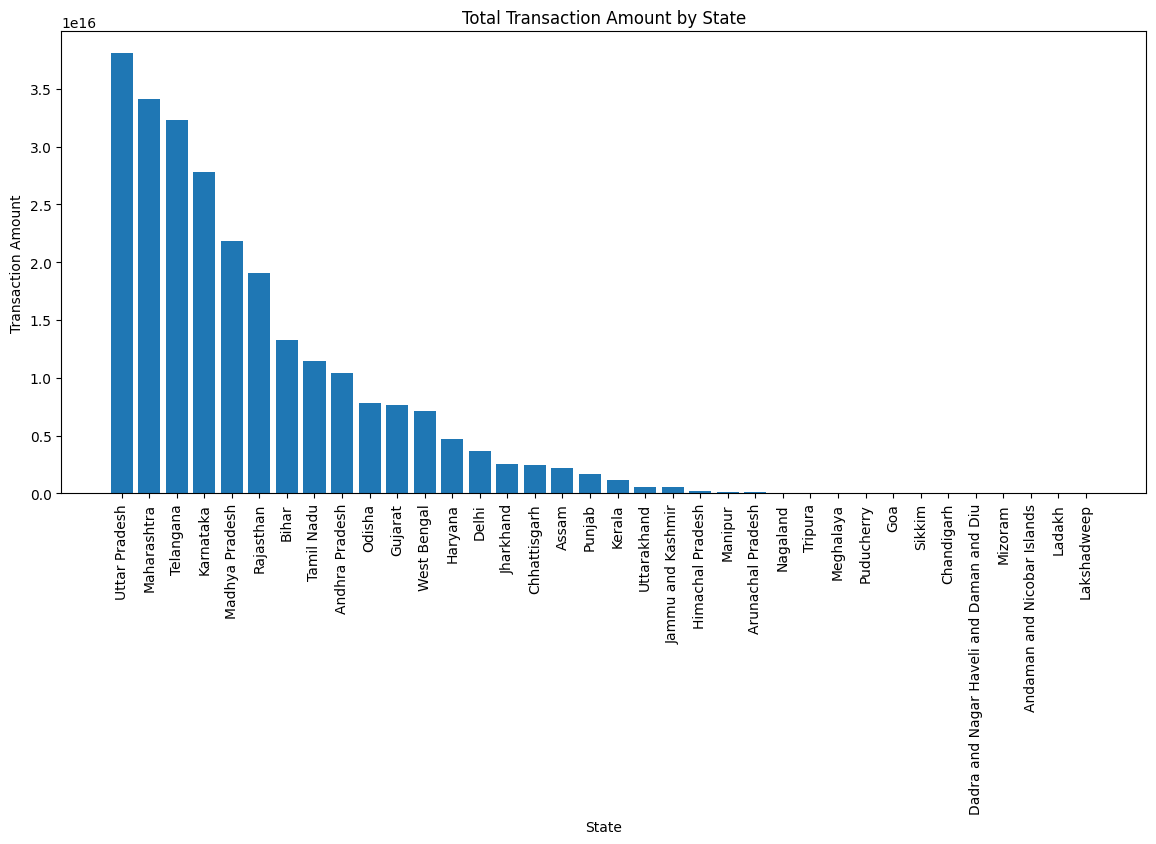

In [52]:
plt.figure(figsize=(14,6))
plt.bar(total.index, total.values)

plt.title("Total Transaction Amount by State")
plt.xlabel("State")
plt.ylabel("Transaction Amount")

plt.xticks(rotation=90)
plt.show()

##  Districts by registered users

# <span style ="color:red;">Top District Analysis</span>

District-wise analysis helps identify the regions generating the highest transaction volume and user activity.

In [53]:
phonepe.groupby('District')['Registered_users'].sum().sort_values(ascending=False)

District
Bengaluru Urban    69292178450
Pune               44432377550
Jaipur             27953063050
Thane              27062940850
Mumbai Suburban    26743374350
                      ...     
Pakke Kessang          3855500
Pherzawl               3364350
Dibang Valley          3243350
Shi Yomi               2589400
Muzaffarabad           2519550
Name: Registered_users, Length: 727, dtype: int64

# Top 20 districts by registered users

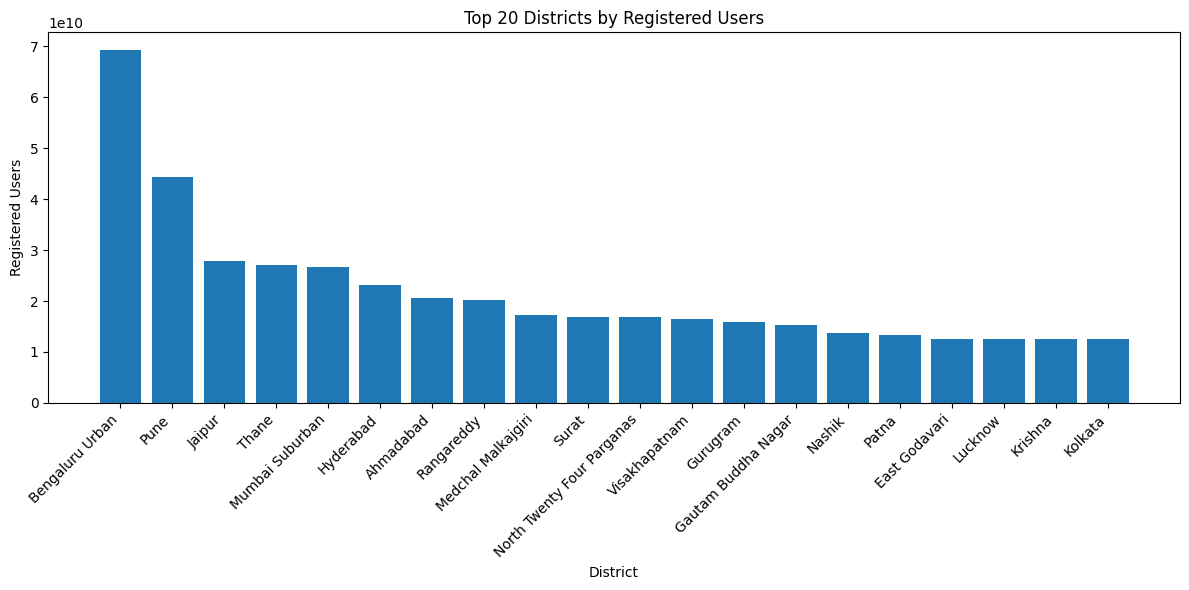

In [54]:
import matplotlib.pyplot as plt


top10 = (
    phonepe.groupby('District')['Registered_users']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
plt.bar(top10.index, top10.values)

plt.title('Top 20 Districts by Registered Users')
plt.xlabel('District')
plt.ylabel('Registered Users')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## Most popular mobile brand

In [55]:
phonepe.groupby('Brand')['Registered_users'].sum().sort_values(ascending=False)

Brand
Xiaomi        172995621798
Vivo          172995621798
Realme        172995621798
Samsung       172995621798
Others        172995621798
Oppo          172995621798
Motorola      166944450404
Huawei        161761338253
Apple         154533514798
OnePlus       134649106768
Lenovo        127350160755
Tecno          43558390265
Micromax       26891445060
Infinix        17758398915
Asus           12610914450
Gionee         10872474744
Lava            6047473900
HMD Global      1996627650
Lyf                3799000
COOLPAD              14028
Name: Registered_users, dtype: int64

## Total app opens by state

In [56]:
phonepe.groupby('State')['App_opens'].sum().sort_values(ascending=False)

State
Maharashtra                                 6545145844050
Karnataka                                   6075286853900
Andhra Pradesh                              5122271020900
Rajasthan                                   5004668108000
Telangana                                   4631993951750
Uttar Pradesh                               3608909324350
Madhya Pradesh                              3576208666800
Tamil Nadu                                  1978923481150
Odisha                                      1926818110800
Bihar                                       1886128356750
West Bengal                                 1706960109250
Gujarat                                     1641667810200
Haryana                                     1358594646750
Delhi                                       1214184149200
Chhattisgarh                                 964457871850
Jharkhand                                    929145991950
Kerala                                       521813164400
Assam   

# Create a pivot table app opens by state

In [57]:
pivot_table = phonepe.pivot_table(
    values='App_opens',
    index='State',
    columns='Year',
    aggfunc='sum'
)


In [58]:
ptable1= pivot_table.drop(columns=[2018], inplace=True)

In [59]:
pivot_table 

Year,2019,2020,2021,2022
State,,,,
Andaman and Nicobar Islands,220417450,1045787050,4667901700,2116073850
Andhra Pradesh,441941671050,1400428915050,2589768149650,690132285150
Arunachal Pradesh,2450202150,7953778250,25444378300,22780207450
Assam,32638896400,89979949400,233554926000,154903349150
Bihar,181569529350,542307031200,987906416750,174345379450
Chandigarh,5943197150,11010545700,16849919900,1276926750
Chhattisgarh,64266230050,181245106900,472269644000,246676890900
Dadra and Nagar Haveli and Daman and Diu,3839921910,9562501080,17096128830,1935842040
Delhi,208887397400,415016261000,558642206650,31638284150


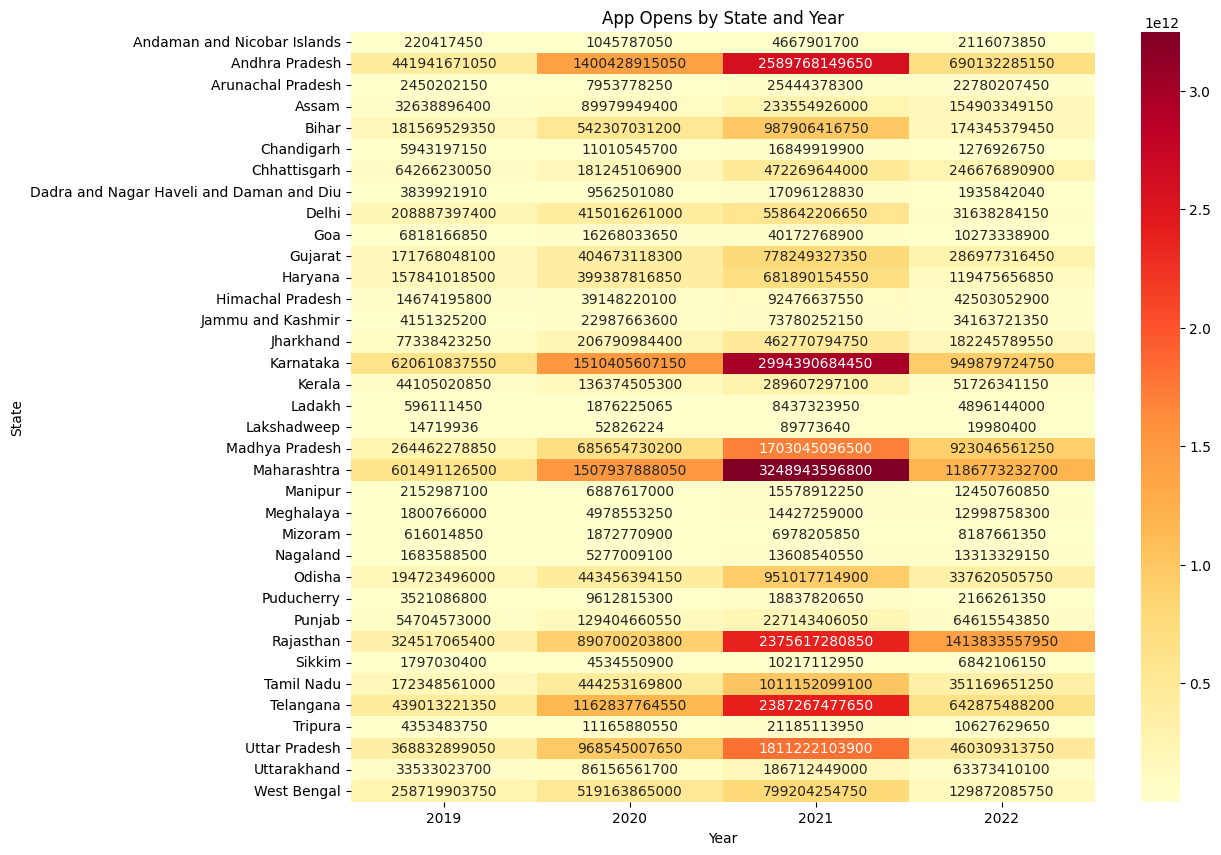

In [60]:

plt.figure(figsize=(12,10))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('App Opens by State and Year')
plt.xlabel('Year')
plt.ylabel('State')

plt.show()

## Transaction count by transaction type

In [61]:
phonepe.groupby('Transaction_type')['Transaction_count_trans'].sum()

Transaction_type
Financial Services            215358964689
Merchant payments           58240118049069
Others                        574178322707
Peer-to-peer payments       61163978820890
Recharge & bill payments    23646225592264
Name: Transaction_count_trans, dtype: int64

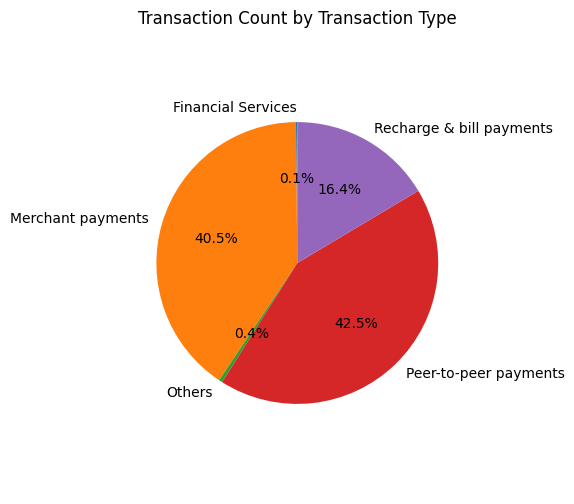

In [62]:

transaction = phonepe.groupby('Transaction_type')['Transaction_count_trans'].sum()
plt.figure(figsize=(4,6))
plt.pie(
    transaction,
    labels=transaction.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Transaction Count by Transaction Type')
plt.axis('equal')
plt.show()

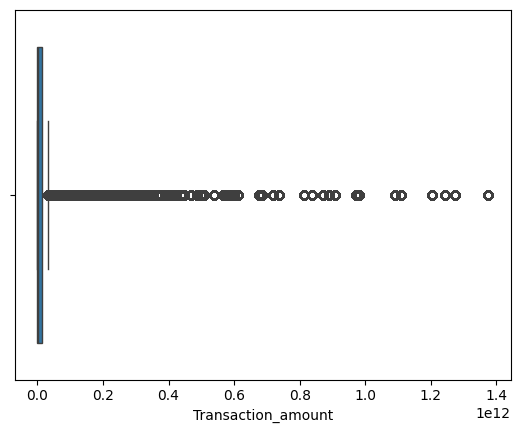

In [63]:
import seaborn as sns

sns.boxplot(x=phonepe['Transaction_amount'])
plt.show()

## Revenue Contribution

In [64]:
state=phonepe.groupby('State')['Transaction_amount'].sum()

share=(state/state.sum())*100

share.sort_values(ascending=False).head(10)

State
Uttar Pradesh     15.158924
Maharashtra       13.573701
Telangana         12.847222
Karnataka         11.087662
Madhya Pradesh     8.711084
Rajasthan          7.607025
Bihar              5.272704
Tamil Nadu         4.543540
Andhra Pradesh     4.154491
Odisha             3.102683
Name: Transaction_amount, dtype: float64

## Average percentage by brand

In [65]:
phonepe.groupby('Brand')['Percentage'].mean()

Brand
Apple          2.972867
Asus           1.718993
COOLPAD        1.996008
Gionee         1.675093
HMD Global     0.865001
Huawei         1.779346
Infinix        1.346970
Lava           1.401533
Lenovo         1.835499
Lyf            1.698798
Micromax       2.475415
Motorola       2.156301
OnePlus        2.167057
Oppo          11.706702
Others         9.260374
Realme         6.120108
Samsung       19.138935
Tecno          1.379507
Vivo          16.854971
Xiaomi        26.250159
Name: Percentage, dtype: float64

## Total registered users by region

In [66]:
phonepe.groupby('Region')['Registered_users'].sum()

Region
Central Region          324922946150
Eastern Region          304914204650
North-Eastern Region     31003370750
Northern Region         217713152195
Southern Region         555820840278
Western Region          468577325755
Name: Registered_users, dtype: int64

# Region wise Group data

In [67]:

region = (
    phonepe.groupby('Region')['Registered_users']
    .sum()
    .reset_index()
)

In [68]:
region

,Region,Registered_users
0,Central Region,324922946150
1,Eastern Region,304914204650
2,North-Eastern Region,31003370750
3,Northern Region,217713152195
4,Southern Region,555820840278
5,Western Region,468577325755


# Treemap

In [69]:
fig = px.treemap(
    region,
    path=['Region'],
    values='Registered_users',
    color='Registered_users',
    color_continuous_scale='Blues',
    title='Registered Users by Region'
)

fig.show()

## Top 10 states with highest growth in registered users

In [70]:
phonepe.groupby('State')['Registered_users'].sum().sort_values(ascending=False).head(10)

State
Maharashtra       248641256050
Uttar Pradesh     195783298150
Karnataka         160255029000
Andhra Pradesh    123978159250
Rajasthan         118605073400
Telangana         116549264150
West Bengal       113371376250
Tamil Nadu        106515765400
Gujarat            99402219400
Madhya Pradesh     99364345300
Name: Registered_users, dtype: int64

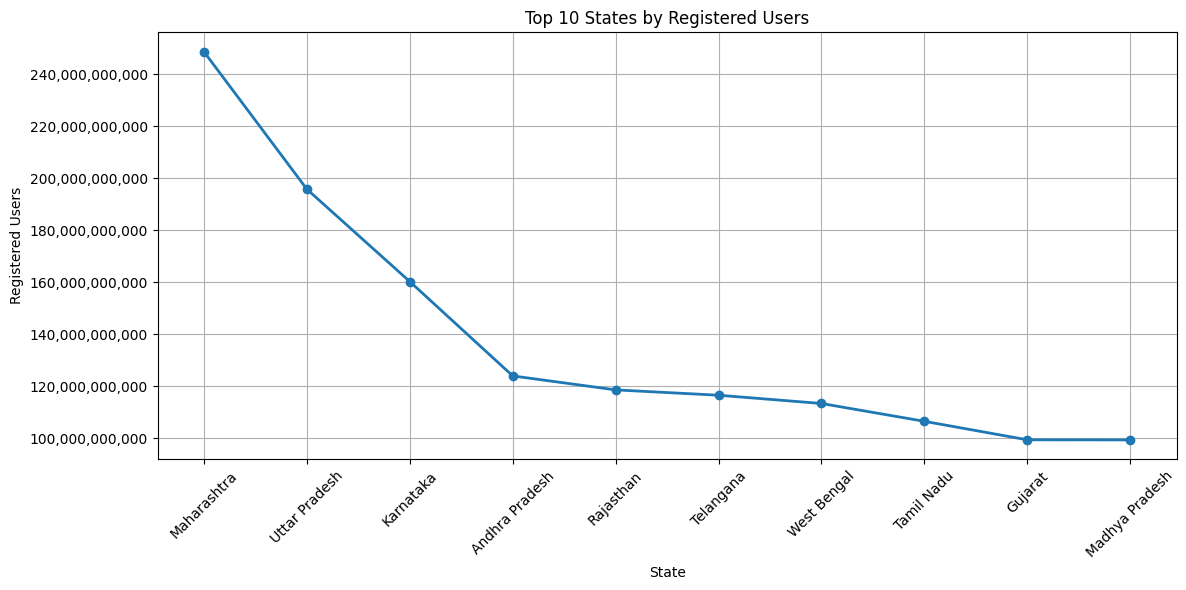

In [71]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

top10 = (
    phonepe.groupby('State')['Registered_users']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
plt.plot(top10.index, top10.values, marker='o', linewidth=2)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.title('Top 10 States by Registered Users')
plt.xlabel('State')
plt.ylabel('Registered Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Transaction amount by year

In [72]:
phonepe.groupby('Year')['Transaction_amount'].sum()

Year
2018    5.821298e+15
2019    2.231098e+16
2020    5.176711e+16
2021    1.234944e+17
2022    4.770763e+16
Name: Transaction_amount, dtype: float64

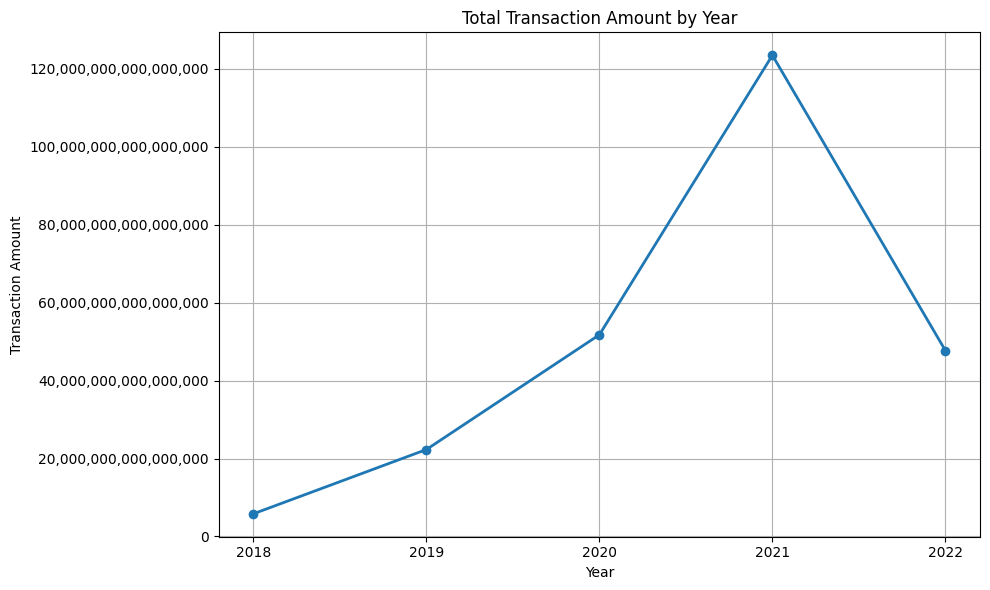

In [73]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


yearly = (
    phonepe.groupby('Year')['Transaction_amount']
    .sum()
    .sort_index()
)


plt.figure(figsize=(10, 6))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2)


plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.title('Total Transaction Amount by Year')
plt.xlabel('Year')
plt.ylabel('Transaction Amount')
plt.xticks(yearly.index)
plt.grid(True)

plt.tight_layout()
plt.show()

## Quarterly transaction analysis

In [74]:
phonepe.groupby(['Year', 'Quarter'])['Transaction_amount'].sum()

Year  Quarter
2018  1          6.164954e+14
      2          1.101660e+15
      3          1.688667e+15
      4          2.414475e+15
2019  1          3.540927e+15
      2          4.848806e+15
      3          5.923525e+15
      4          7.997721e+15
2020  1          9.569829e+15
      2          9.410769e+15
      3          1.371511e+16
      4          1.907141e+16
2021  1          2.234131e+16
      2          2.672045e+16
      3          3.268480e+16
      4          4.174788e+16
2022  1          4.770763e+16
Name: Transaction_amount, dtype: float64

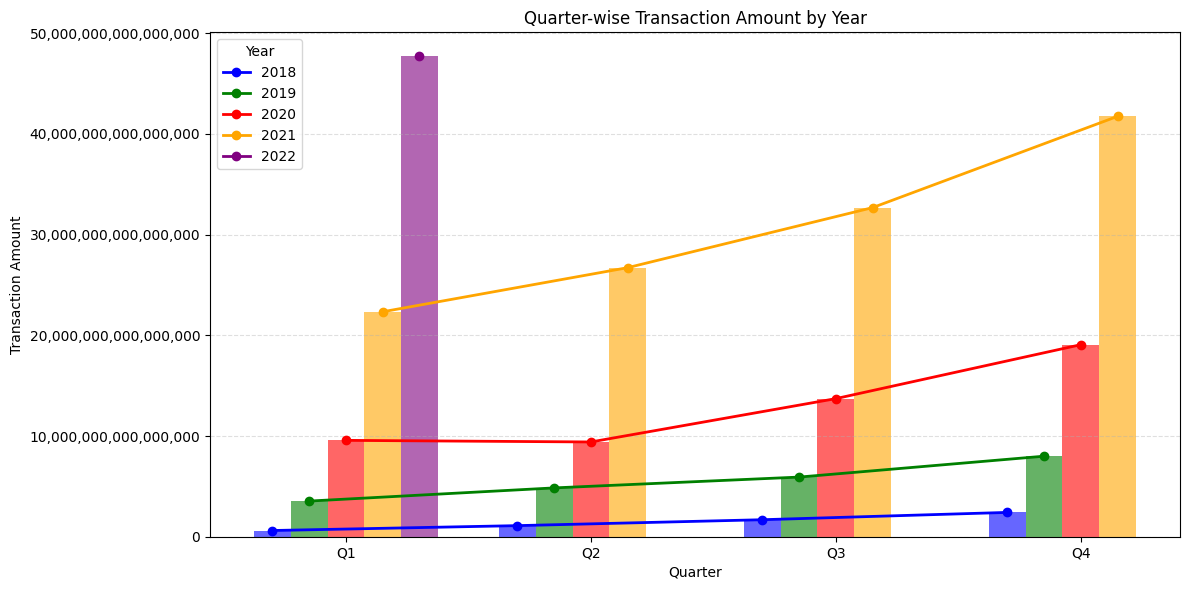

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


data = phonepe.groupby(['Year', 'Quarter'])['Transaction_amount'].sum().unstack()


plt.figure(figsize=(12,6))

colors = ['blue', 'green', 'red', 'orange', 'purple']

bar_width = 0.15
quarters = data.columns
x = range(len(quarters))

# Plot bars and lines
for i, year in enumerate(data.index):
    xpos = [p + i*bar_width for p in x]

   
    plt.bar(
        xpos,
        data.loc[year],
        width=bar_width,
        color=colors[i],
        alpha=0.6
    )

    
    plt.plot(
        xpos,
        data.loc[year],
        marker='o',
        linewidth=2,
        color=colors[i],
        label=str(year)
    )

# X-axis
plt.xticks(
    [p + bar_width*2 for p in x],
    ['Q1', 'Q2', 'Q3', 'Q4']
)

# Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.xlabel("Quarter")
plt.ylabel("Transaction Amount")
plt.title("Quarter-wise Transaction Amount by Year")
plt.legend(title="Year")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## State-wise yearly transaction trend

In [76]:
t1 = phonepe.pivot_table(
    values='Transaction_amount',
    index='State',
    columns='Year',
    aggfunc='sum'
)

t1.style.format('{:,.0f}')

Year,2018,2019,2020,2021,2022
State,,,,,
Andaman and Nicobar Islands,"62,395,114,304","156,243,369,797","427,819,727,392","1,625,411,066,611","702,579,966,683"
Andhra Pradesh,"174,562,980,978,829","769,041,665,419,041","2,398,462,610,335,020","5,239,040,452,264,119","1,850,878,524,573,478"
Arunachal Pradesh,"3,020,889,061,648","9,531,016,536,195","25,818,864,779,730","57,452,557,865,752","21,527,251,977,220"
Assam,"47,943,397,209,632","171,297,871,356,645","401,088,613,720,539","1,054,167,990,474,232","480,177,989,550,501"
Bihar,"284,598,187,665,931","1,110,381,368,134,069","2,718,245,035,590,266","6,570,911,010,036,215","2,555,700,888,156,165"
Chandigarh,"547,426,519,410","1,376,247,846,044","2,223,104,515,987","4,642,391,744,624","1,669,249,070,484"
Chhattisgarh,"65,732,175,844,325","227,187,061,137,066","501,545,975,940,158","1,155,757,184,908,039","468,805,725,000,845"
Dadra and Nagar Haveli and Daman and Diu,"470,483,452,367","1,145,209,365,182","2,107,345,691,589","4,750,538,718,937","1,852,403,365,076"
Delhi,"115,865,374,908,024","450,600,645,062,584","765,832,029,778,907","1,719,921,918,739,839","649,727,554,211,899"


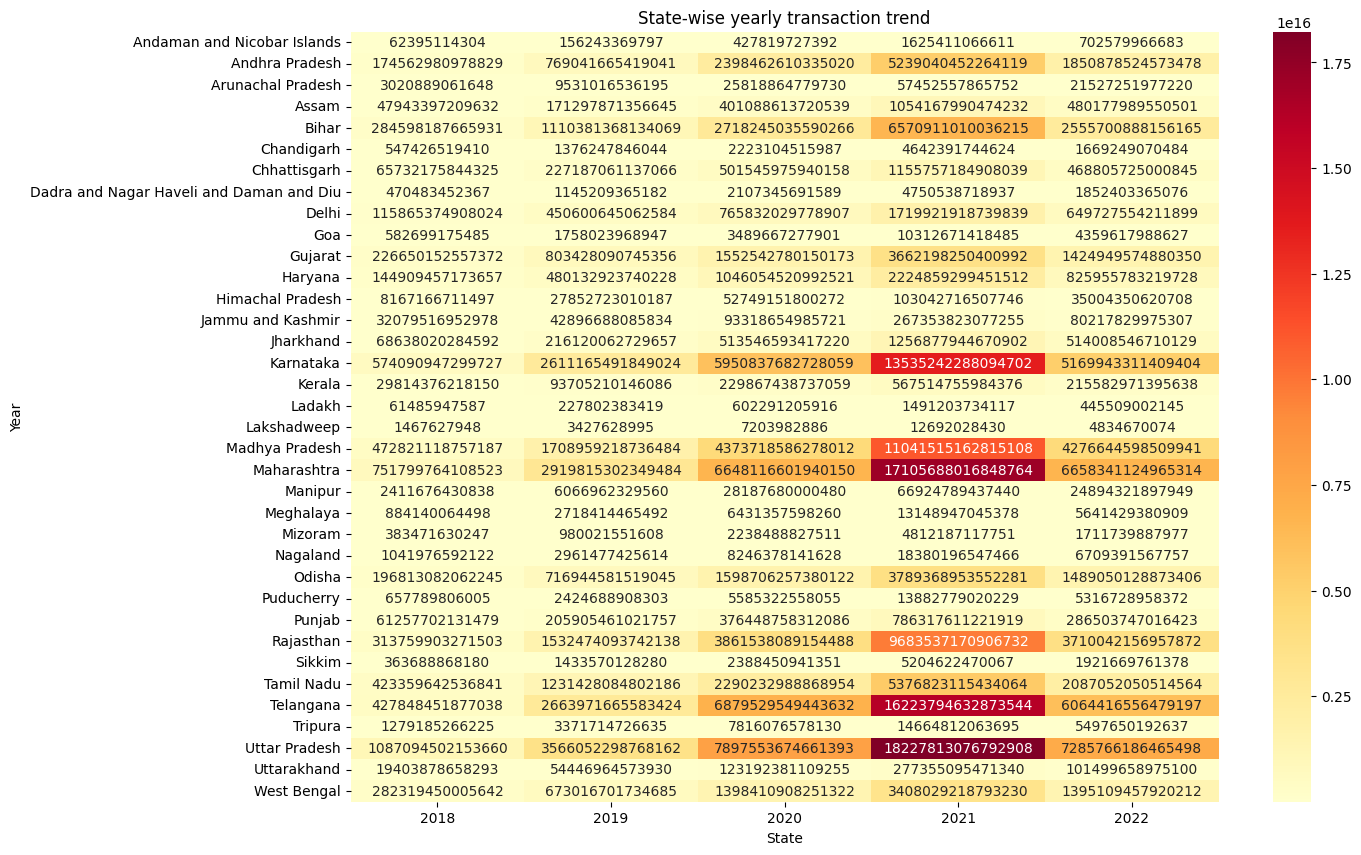

In [77]:
plt.figure(figsize=(14,10))
sns.heatmap(
    t1,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('State-wise yearly transaction trend')
plt.xlabel('State')#State
plt.ylabel('Year')#Year

plt.show()

## Brand-wise market share

In [78]:
Brand_share=phonepe.groupby('Brand')['Percentage'].mean().sort_values(ascending=False)
Brand_share

Brand
Xiaomi        26.250159
Samsung       19.138935
Vivo          16.854971
Oppo          11.706702
Others         9.260374
Realme         6.120108
Apple          2.972867
Micromax       2.475415
OnePlus        2.167057
Motorola       2.156301
COOLPAD        1.996008
Lenovo         1.835499
Huawei         1.779346
Asus           1.718993
Lyf            1.698798
Gionee         1.675093
Lava           1.401533
Tecno          1.379507
Infinix        1.346970
HMD Global     0.865001
Name: Percentage, dtype: float64

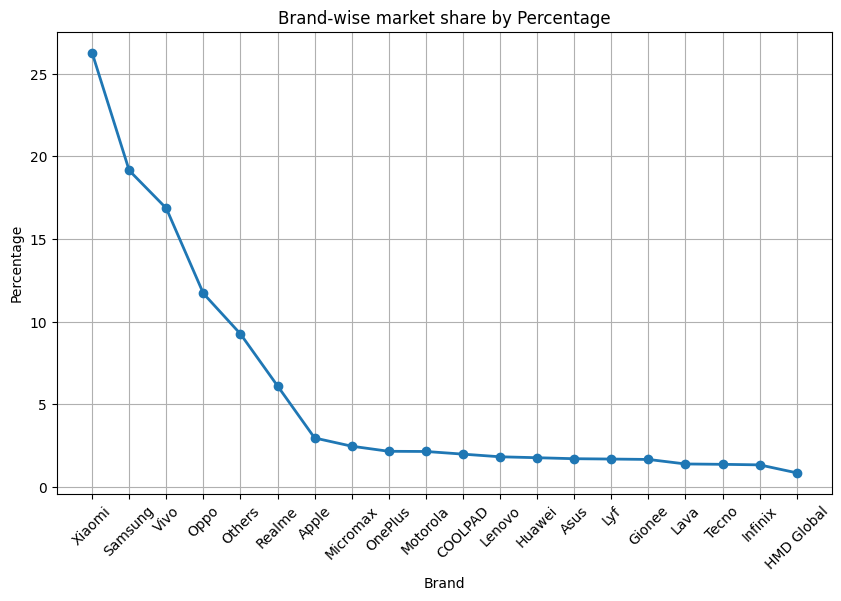

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(Brand_share.index, Brand_share.values, marker='o', linewidth=2)

plt.title('Brand-wise market share by Percentage')
plt.xlabel('Brand')
plt.ylabel('Percentage')
plt.xticks(Brand_share.index, rotation=45)
plt.grid(True)





plt.show()

## Top 20 pincodes by users

In [80]:
phonepe.groupby(['State', 'Pincode'])['Registered_users'].sum().sort_values(ascending=False).head(20)

State          Pincode
Maharashtra    411033     24864125605
               411057     24864125605
               411014     24864125605
               410501     23558134270
               411004     19665497720
Uttar Pradesh  201307     19578329815
               201301     19578329815
               201308     19578329815
               201009     19133023250
               201304     18965805595
Maharashtra    400070     18359506385
Uttar Pradesh  226004     17951691010
Karnataka      560100     16025502900
               560078     16025502900
               560076     16025502900
               560068     16025502900
               560001     16025502900
               560037     16025502900
Maharashtra    444510     15192721720
Uttar Pradesh  250001     14867571015
Name: Registered_users, dtype: int64

## State with maximum app opens

In [81]:
phonepe.groupby('State')['App_opens'].sum().idxmax()

'Maharashtra'

## District with highest transaction amount

In [82]:
phonepe.groupby('District')['Transaction_amount'].sum().sort_values(ascending=False).head()

District
Aurangabad    1.295188e+15
Pratapgarh    1.086353e+15
Jagtial       9.775625e+14
Hyderabad     9.775625e+14
Adilabad      9.775625e+14
Name: Transaction_amount, dtype: float64

## Year-over-year transaction growth

In [83]:
yearly = phonepe.groupby('Year')['Transaction_amount'].sum()

growth = yearly.pct_change()*100

growth

Year
2018           NaN
2019    283.264676
2020    132.025269
2021    138.557721
2022    -61.368597
Name: Transaction_amount, dtype: float64

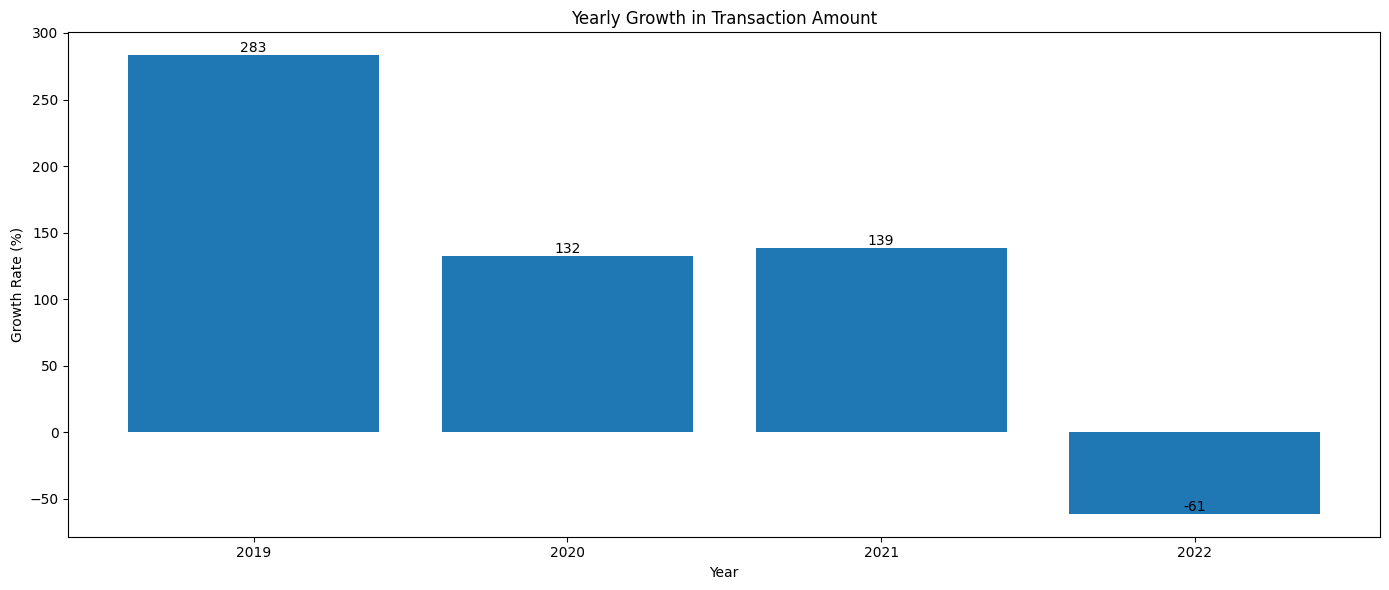

In [84]:


plt.figure(figsize=(14,6))

bars = plt.bar(growth.index.astype(str), growth.values)

plt.title("Yearly Growth in Transaction Amount")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## State-wise Transaction Amount

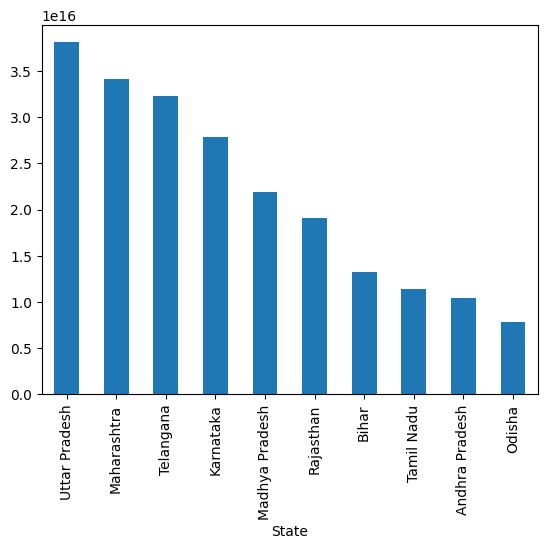

In [85]:


phonepe.groupby('State')['Transaction_amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.show()

## Brand-wise Users

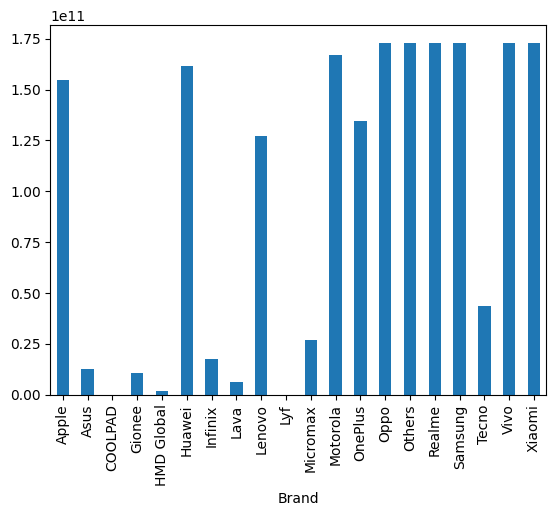

In [86]:
phonepe.groupby('Brand')['Registered_users'].sum().plot(kind='bar')

plt.show()

## Yearly Transaction Trend

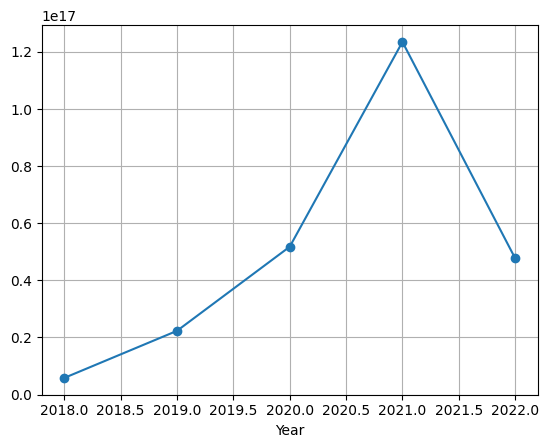

In [87]:
phonepe.groupby('Year')['Transaction_amount'].sum().plot(marker='o')
plt.grid(True)

plt.show()

<Axes: >

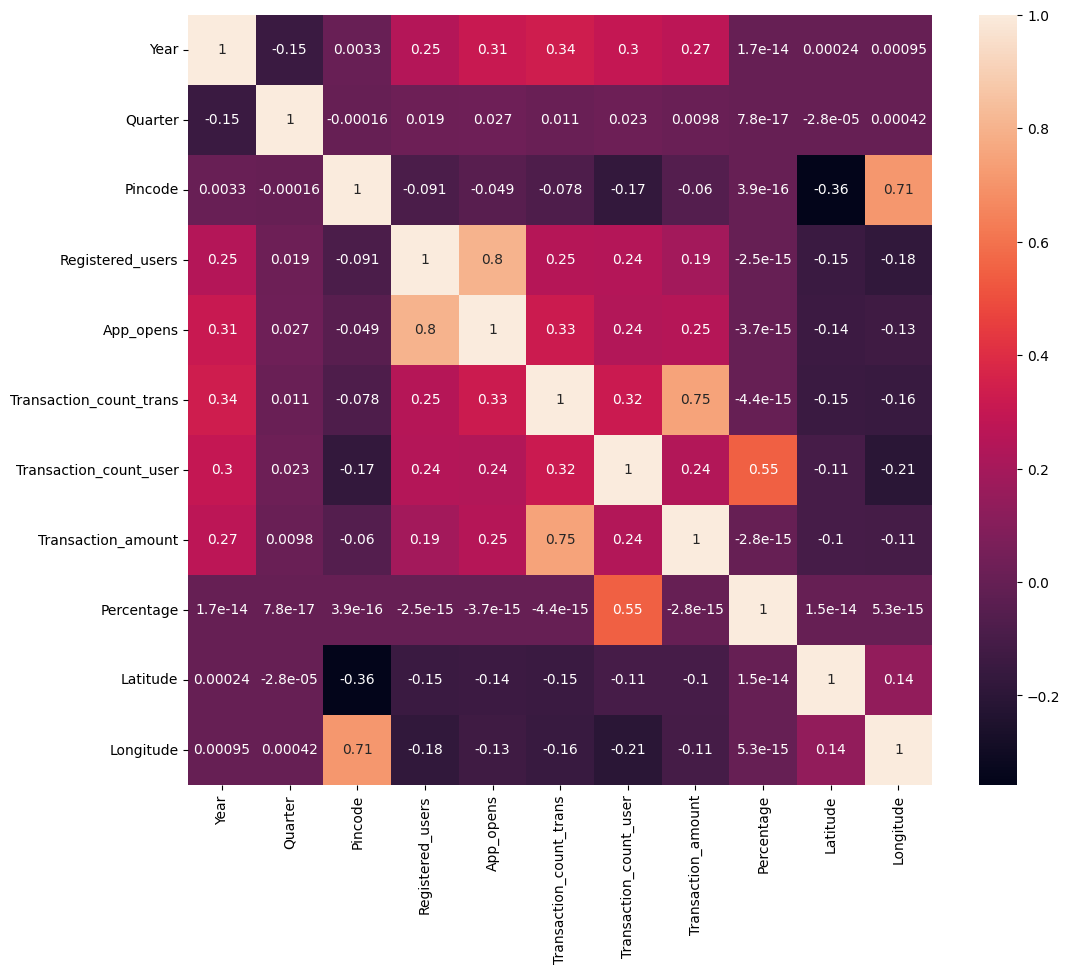

In [89]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(phonepe.corr(numeric_only=True),annot=True)


# <span style="color:Green">Conclusion</span>

This project successfully analyzed the PhonePe Pulse dataset using Python.

The analysis demonstrates significant growth in digital payments across India and identifies the states, districts, and pincodes contributing the highest transaction volumes.

By applying data cleaning, preprocessing, exploratory data analysis, and visualization techniques, meaningful business insights were generated that can support strategic decision-making.

This project also demonstrates practical skills in Python, Pandas, NumPy, and data visualization, making it a strong addition to a data analytics portfolio.

#  Future Scope

The project can be enhanced by:

- Developing an interactive Power BI dashboard.
- Creating a Tableau dashboard.
- Building a Streamlit web application.
- Applying Machine Learning for transaction forecasting.
- Integrating real-time data through APIs.
- Automating report generation.

# Thank You

Thank you for reviewing this project.

This project demonstrates practical applications of Python in data analytics, including data preprocessing, exploratory data analysis, and business insight generation using the PhonePe Pulse dataset.

---

### Developed By

**Suraj Sahu**

**Python Data Analytics Project**

 Thank You!